# Trucking Time Series Project

In this project, we develop a time series forecasting model to predict heavy-duty truck prices.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSIAfxqxBeIo4NbxFADPRbTMlzK1Qc_agH_f3EM1Msi1r7EAPmwpCSqNxQ&s=10' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

### EDA

In [2]:
df=pd.read_csv('Truck_sales.csv')

In [3]:
df.head()

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


In [4]:
df.tail()

,Month-Year,Number_Trucks_Sold
139,14-Aug,933
140,14-Sep,704
141,14-Oct,639
142,14-Nov,571
143,14-Dec,666


In [5]:
df.shape

(144, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Month-Year          144 non-null    object
 1   Number_Trucks_Sold  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [7]:
df.isnull().sum()

Month-Year            0
Number_Trucks_Sold    0
dtype: int64

In [9]:
df['Number_Trucks_Sold'].value_counts()

Number_Trucks_Sold
307    3
185    2
318    2
590    2
274    2
      ..
398    1
363    1
287    1
272    1
666    1
Name: count, Length: 123, dtype: int64

In [10]:
df['Month-Year'].value_counts()

Month-Year
03-Jan    1
03-Feb    1
10-Sep    1
10-Oct    1
10-Nov    1
         ..
07-Jan    1
07-Feb    1
07-Mar    1
07-Apr    1
14-Dec    1
Name: count, Length: 144, dtype: int64

In [11]:
df.describe()

,Number_Trucks_Sold
count,144.000000
mean,428.729167
std,188.633037
min,152.000000
25%,273.500000
50%,406.000000
75%,560.250000
max,958.000000


In [12]:
df = (
    df.assign(**{'Month-Year': pd.to_datetime(df['Month-Year'], format='%y-%b')})
      .set_index('Month-Year')
      .asfreq('MS')
)

print(df.head())

            Number_Trucks_Sold
Month-Year                    
2003-01-01                 155
2003-02-01                 173
2003-03-01                 204
2003-04-01                 219
2003-05-01                 223


In [14]:
# Monthly Start
df = df.asfreq('MS')  

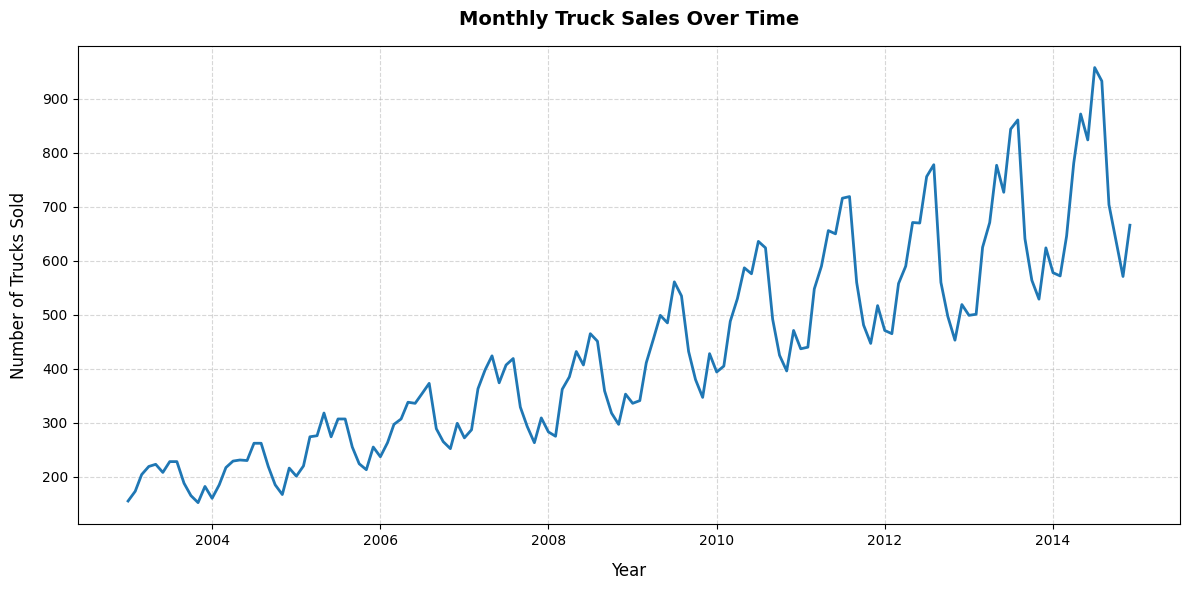

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(df['Number_Trucks_Sold'], color='#1f77b4', linewidth=2)

plt.title("Monthly Truck Sales Over Time", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("Number of Trucks Sold", fontsize=12, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [16]:
from statsmodels.tsa.stattools import adfuller

# Check stationarity
adf_stat, p_value, *rest = adfuller(df['Number_Trucks_Sold'])
print(f"ADF Statistic: {adf_stat:.4f} | p-value: {p_value:.4f}")

ADF Statistic: 1.1159 | p-value: 0.9954


### Sarima Model

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    df['Number_Trucks_Sold'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit()

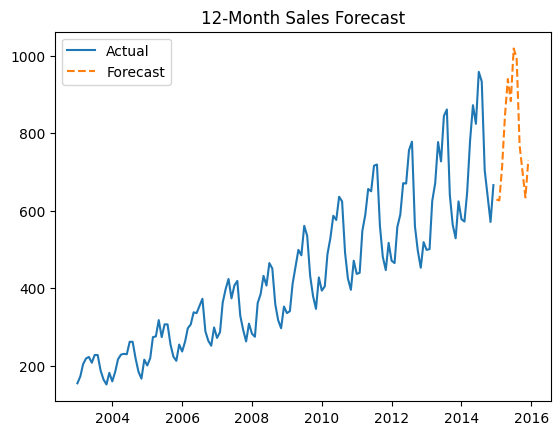

In [19]:
forecast = model_fit.forecast(steps=12)

plt.figure()
plt.plot(df['Number_Trucks_Sold'], label="Actual")
plt.plot(forecast, label="Forecast", linestyle="--")
plt.legend()
plt.title("12-Month Sales Forecast")
plt.show()

The sales data shows a strong upward trend from 2003 to 2014, together with a clear yearly seasonality: sales peak in the middle of each year and drop at the beginning and end of the year, and the size of these swings grows as the overall level rises. The 12-month forecast follows this pattern well. It predicts sales climbing to a new peak of about 1,000 units in mid-2015, above the previous peak of about 960, and then falling back to around 650-700 by the end of the year. This suggests the model captured both the trend and the seasonal cycle.

### Prophet Modeling

In [20]:
from prophet import Prophet

In [21]:
df_p = df.reset_index().rename(columns={'Month-Year': 'ds', 'Number_Trucks_Sold': 'y'})

In [22]:
model = Prophet(yearly_seasonality=True)
model.fit(df_p)

16:45:19 - cmdstanpy - INFO - Chain [1] start processing
16:45:20 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

In [24]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))

            ds        yhat  yhat_lower  yhat_upper
144 2015-01-01  673.061856  624.565432  725.314575
145 2015-02-01  681.372022  632.705347  728.956434
146 2015-03-01  755.140563  707.047527  802.665748
147 2015-04-01  795.751728  746.141708  843.763040
148 2015-05-01  843.879788  796.541145  890.864139
149 2015-06-01  821.635009  772.552483  873.779675
150 2015-07-01  880.454220  832.333222  929.267316
151 2015-08-01  881.129352  829.155554  934.755174
152 2015-09-01  762.852183  715.212761  812.984686
153 2015-10-01  715.518031  665.897414  763.733604
154 2015-11-01  687.596653  638.661605  736.854810
155 2015-12-01  748.015425  699.788223  793.980137


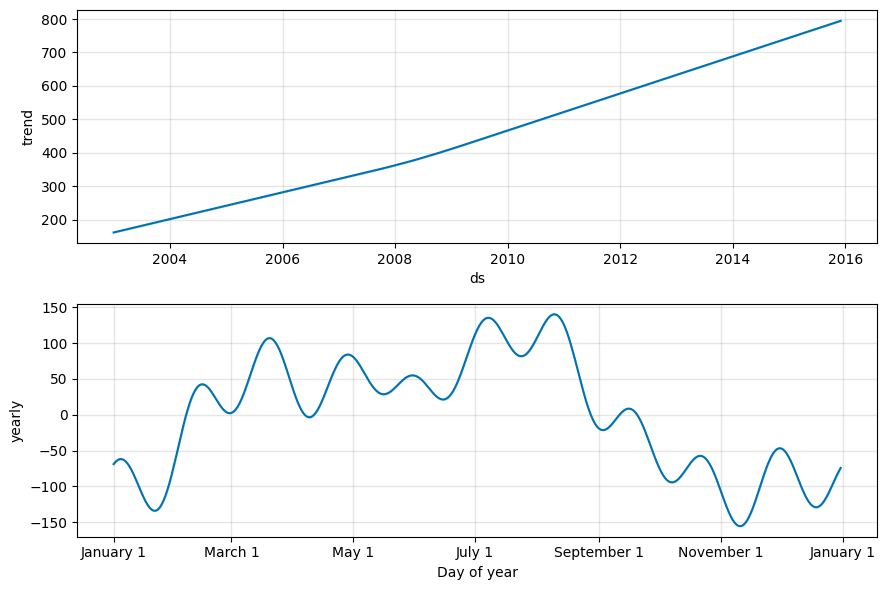

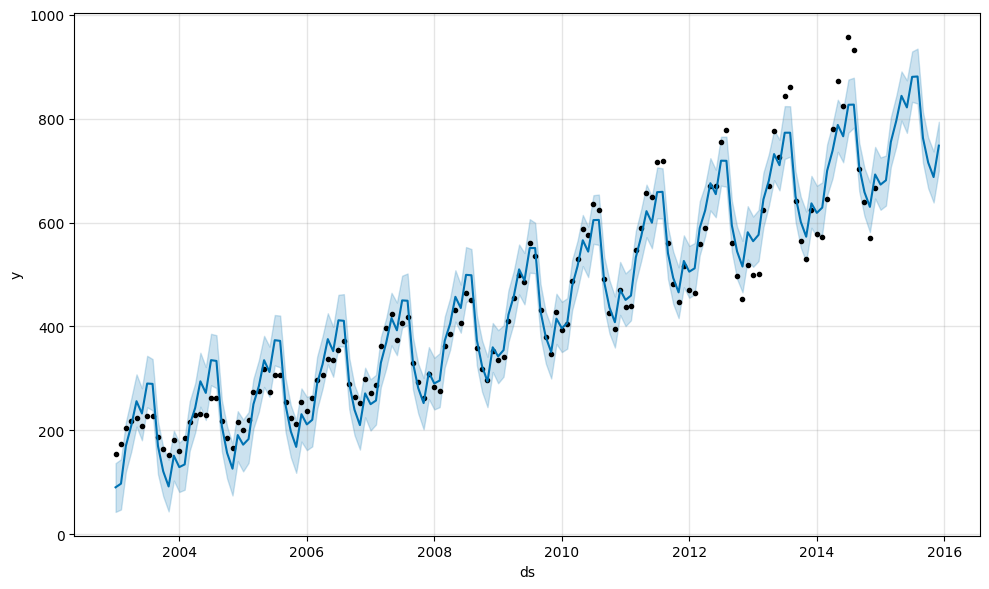

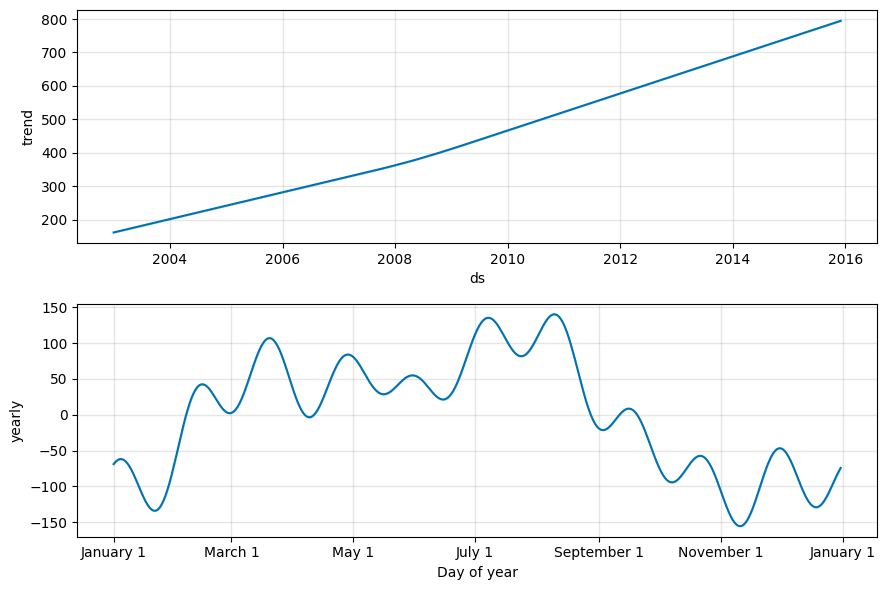

In [25]:
model.plot(forecast)
model.plot_components(forecast)